# 04 — Programación Lineal

**Curso:** Inteligencia Artificial — Optimización (Clase 3)

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.
Los dos ejemplos son exactamente los que se formalizan en las slides de la
Clase 3, para que la transición slide → notebook no introduzca un problema
nuevo que el estudiante no haya visto formulado antes.

## Objetivos

- formular variables de decisión, función objetivo y restricciones;
- visualizar la región factible de un problema con dos variables;
- resolver un problema mediante enumeración de vértices y `scipy.optimize.linprog`;
- interpretar holguras y restricciones activas;
- convertir una restricción `≥` a la forma estándar `≤` que esperan los solvers.

![Descripción](https://drive.google.com/uc?export=view&id=1lNBEfy3ZR_bHsx-LJz1L7gip_C9ZEKSb)

## 1. Problema de producción: sillas y mesas

Una fábrica produce **sillas** ($x_1$) y **mesas** ($x_2$). Cada silla deja
\$25 de ganancia y cada mesa \$30.

| Recurso | Silla ($x_1$) | Mesa ($x_2$) | Disponible |
|---|---:|---:|---:|
| Madera | 2 unidades | 3 unidades | 120 unidades |
| Mano de obra | 1 h | 1 h | 50 h |

Modelo:

$$
\max 25x_1+30x_2
$$

sujeto a

$$
2x_1+3x_2\leq120
$$

$$
x_1+x_2\leq50
$$

$$
x_1,x_2\geq0
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

## 2. Visualización de la región factible

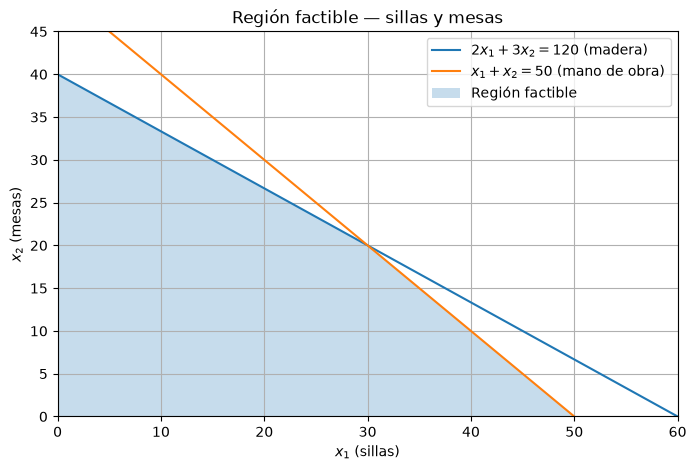

In [2]:
x1 = np.linspace(0, 60, 500)
constraint_1 = (120 - 2 * x1) / 3
constraint_2 = 50 - x1
upper = np.minimum(constraint_1, constraint_2)
upper = np.maximum(upper, 0)

plt.figure(figsize=(8, 5))
plt.plot(x1, constraint_1, label=r'$2x_1+3x_2=120$ (madera)')
plt.plot(x1, constraint_2, label=r'$x_1+x_2=50$ (mano de obra)')
plt.fill_between(x1, 0, upper, where=(upper >= 0), alpha=0.25, label='Región factible')
plt.xlim(0, 60)
plt.ylim(0, 45)
plt.xlabel(r'$x_1$ (sillas)')
plt.ylabel(r'$x_2$ (mesas)')
plt.title('Región factible — sillas y mesas')
plt.legend()
plt.grid(True)
plt.show()

## 3. Solución mediante vértices

En un problema lineal con una región factible acotada, si existe un óptimo, al menos un vértice es óptimo. Para dos variables podemos calcularlos explícitamente.

In [3]:
# Intersección entre las dos restricciones.
A = np.array([[2, 3], [1, 1]], dtype=float)
b = np.array([120, 50], dtype=float)
intersection = np.linalg.solve(A, b)

vertices = [
    np.array([0.0, 0.0]),
    np.array([50.0, 0.0]),   # x1 = 50 satura mano de obra antes que madera (120/2=60 > 50)
    np.array([0.0, 40.0]),   # x2 = 40 satura madera antes que mano de obra (120/3=40 < 50)
    intersection
]


def profit(x):
    return 25 * x[0] + 30 * x[1]

for vertex in vertices:
    print(f'x={vertex}, utilidad={profit(vertex):.2f}')

best_vertex = max(vertices, key=profit)
print()
print('Mejor vértice:', best_vertex)
print('Utilidad máxima:', profit(best_vertex))

x=[0. 0.], utilidad=0.00
x=[50.  0.], utilidad=1250.00
x=[ 0. 40.], utilidad=1200.00
x=[30. 20.], utilidad=1350.00

Mejor vértice: [30. 20.]
Utilidad máxima: 1350.0


Nota: con la utilidad original del ejemplo (\$20 por silla en vez de \$25),
el gradiente de la función objetivo queda exactamente paralelo a la
restricción de madera y hay **empate** entre dos vértices (óptimos
múltiples a lo largo de una arista). Con \$25 el óptimo es único — vale la
pena mencionar en clase que ese empate *sí* puede pasar en LP y no es un
error, es una propiedad real cuando el gradiente de la función objetivo
coincide en dirección con una restricción activa.

## 4. Solución con SciPy

`linprog` minimiza. Para maximizar $c^Tx$, minimizamos $-c^Tx$.

In [4]:
c = np.array([-25, -30])
A_ub = np.array([[2, 3], [1, 1]])
b_ub = np.array([120, 50])
bounds = [(0, None), (0, None)]

result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

if not result.success:
    raise RuntimeError(result.message)

print('Solución:', result.x)
print('Utilidad máxima:', -result.fun)
print('Holguras:', result.ineqlin.residual)

Solución: [30. 20.]
Utilidad máxima: 1350.0
Holguras: [0. 0.]


Una holgura igual a cero indica que la restricción está **activa** en la solución. En este problema, ambos recursos se usan completamente.

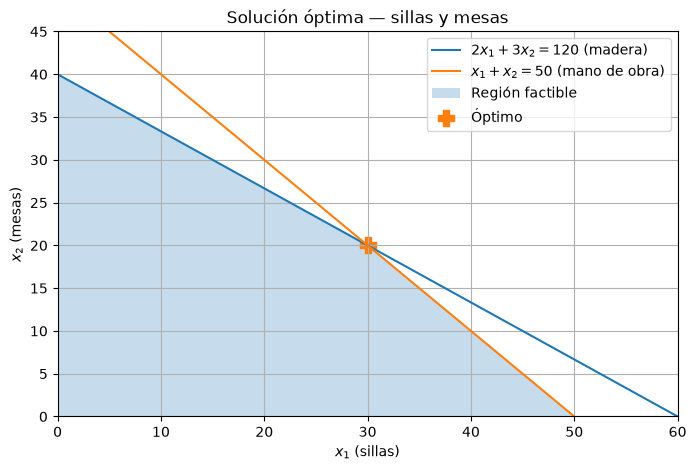

In [5]:
solution = result.x

plt.figure(figsize=(8, 5))
plt.plot(x1, constraint_1, label=r'$2x_1+3x_2=120$ (madera)')
plt.plot(x1, constraint_2, label=r'$x_1+x_2=50$ (mano de obra)')
plt.fill_between(x1, 0, upper, where=(upper >= 0), alpha=0.25, label='Región factible')
plt.scatter([solution[0]], [solution[1]], s=130, marker='P', label='Óptimo')
plt.xlim(0, 60)
plt.ylim(0, 45)
plt.xlabel(r'$x_1$ (sillas)')
plt.ylabel(r'$x_2$ (mesas)')
plt.title('Solución óptima — sillas y mesas')
plt.legend()
plt.grid(True)
plt.show()

## 5. Análisis de sensibilidad básico

Modificaremos la utilidad de la mesa y observaremos cuándo cambia la solución óptima.

In [6]:
profits_b = np.arange(10, 101, 5)
solutions = []

for p_b in profits_b:
    r = linprog([-25, -p_b], A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    solutions.append((p_b, r.x[0], r.x[1], -r.fun))

print('utilidad_mesa | x1 (sillas) | x2 (mesas) | utilidad total')
for p_b, x_1, x_2, value in solutions:
    print(f'{p_b:>13.0f} | {x_1:>11.1f} | {x_2:>10.1f} | {value:>14.1f}')

utilidad_mesa | x1 (sillas) | x2 (mesas) | utilidad total
           10 |        50.0 |        0.0 |         1250.0
           15 |        50.0 |        0.0 |         1250.0
           20 |        50.0 |        0.0 |         1250.0
           25 |        30.0 |       20.0 |         1250.0
           30 |        30.0 |       20.0 |         1350.0
           35 |        30.0 |       20.0 |         1450.0
           40 |         0.0 |       40.0 |         1600.0
           45 |         0.0 |       40.0 |         1800.0
           50 |         0.0 |       40.0 |         2000.0
           55 |         0.0 |       40.0 |         2200.0
           60 |         0.0 |       40.0 |         2400.0
           65 |         0.0 |       40.0 |         2600.0
           70 |         0.0 |       40.0 |         2800.0
           75 |         0.0 |       40.0 |         3000.0
           80 |         0.0 |       40.0 |         3200.0
           85 |         0.0 |       40.0 |         3400.0
           90 

## 6. Segundo ejemplo: dos máquinas (minimización)

Una variante útil porque **minimiza** en vez de maximizar, y porque obliga
a convertir una restricción `≥` a la forma estándar `≤` que espera
`linprog`. Este es el mismo ejemplo que aparece formulado en la slide de
la Clase 3.

- Dos máquinas $x_1, x_2$ (horas de uso). $x_1$ cuesta \$50/hora, $x_2$
  cuesta \$80/hora. **Minimizar**: $50x_1+80x_2$.
- Mano de obra disponible: $x_1$ requiere 5 unidades/hora, $x_2$ requiere
  2 unidades/hora, con 20 unidades totales disponibles:
  $5x_1+2x_2\leq20$.
- Producción mínima requerida: $x_1$ produce 10 unidades/hora, $x_2$
  produce 12 unidades/hora, y se necesitan al menos 90 unidades:
  $10x_1+12x_2\geq90$.

`linprog` solo acepta restricciones en la forma $\leq$, así que
multiplicamos la segunda restricción por $-1$:
$-10x_1-12x_2\leq-90$.

In [7]:
c_machines = [50, 80]
A_ub_machines = [[5, 2], [-10, -12]]
b_ub_machines = [20, -90]

result_machines = linprog(
    c_machines,
    A_ub=A_ub_machines,
    b_ub=b_ub_machines,
    bounds=[(0, None), (0, None)],
    method='highs'
)

if result_machines.success:
    print(f"X1: {round(result_machines.x[0], 2)} horas")
    print(f"X2: {round(result_machines.x[1], 2)} horas")
    print(f"Costo mínimo: {round(result_machines.fun, 2)}")
else:
    print("No solution")

X1: 1.5 horas
X2: 6.25 horas
Costo mínimo: 575.0


## Actividades

### Actividad 1 — Restricción adicional

Agrega una restricción de almacenamiento al problema de sillas y mesas:

$$
4x_1+2x_2\leq160
$$

Grafica la nueva región factible y resuelve el modelo.

Solución: [30. 20.]
Utilidad máxima: 1350.0
Holguras: [0. 0. 0.]


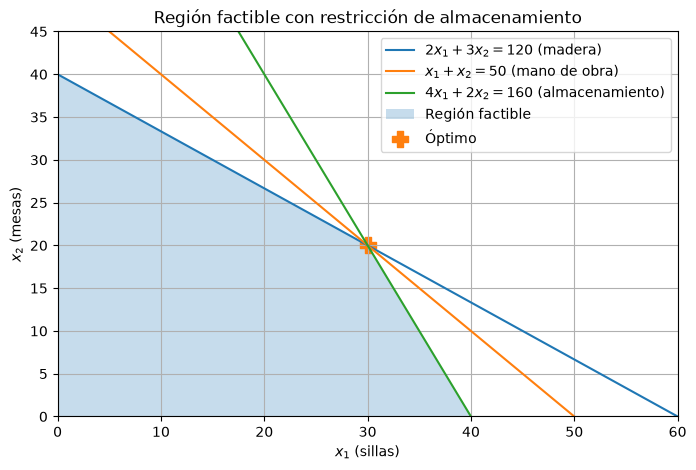

In [8]:
A_ub_extended = np.array([[2, 3], [1, 1], [4, 2]])
b_ub_extended = np.array([120, 50, 160])

result_extended = linprog(c, A_ub=A_ub_extended, b_ub=b_ub_extended, bounds=bounds, method='highs')

if not result_extended.success:
    raise RuntimeError(result_extended.message)

print('Solución:', result_extended.x)
print('Utilidad máxima:', -result_extended.fun)
print('Holguras:', result_extended.ineqlin.residual)

constraint_3 = (160 - 4 * x1) / 2
upper_extended = np.minimum(np.minimum(constraint_1, constraint_2), constraint_3)
upper_extended = np.maximum(upper_extended, 0)

plt.figure(figsize=(8, 5))
plt.plot(x1, constraint_1, label=r'$2x_1+3x_2=120$ (madera)')
plt.plot(x1, constraint_2, label=r'$x_1+x_2=50$ (mano de obra)')
plt.plot(x1, constraint_3, label=r'$4x_1+2x_2=160$ (almacenamiento)')
plt.fill_between(x1, 0, upper_extended, where=(upper_extended >= 0), alpha=0.25, label='Región factible')
plt.scatter([result_extended.x[0]], [result_extended.x[1]], s=130, marker='P', label='Óptimo')
plt.xlim(0, 60)
plt.ylim(0, 45)
plt.xlabel(r'$x_1$ (sillas)')
plt.ylabel(r'$x_2$ (mesas)')
plt.title('Región factible con restricción de almacenamiento')
plt.legend()
plt.grid(True)
plt.show()


**Discusión (Actividad 1).** Al agregar la restricción de almacenamiento $4x_1+2x_2\leq160$, la solución óptima obtenida en `result_extended.x` coincide con la del problema original (`result.x`), y la holgura de la nueva restricción en `result_extended.ineqlin.residual` es positiva: la restricción de almacenamiento no está activa en el óptimo, es decir, no reduce la utilidad máxima porque las restricciones de madera y mano de obra ya eran las que limitaban la producción. Esto ilustra que agregar una restricción no siempre cambia la solución óptima — solo lo hace si "corta" el vértice que ya era óptimo.

### Actividad 2 — Producción mínima

El contrato exige producir al menos 10 mesas:

$$
x_2\geq10
$$

Representa esta condición correctamente en `linprog` y resuelve el problema de sillas y mesas.

In [9]:
# x2 >= 10  equivale a  -x2 <= -10
A_ub_min_production = np.array([[2, 3], [1, 1], [0, -1]])
b_ub_min_production = np.array([120, 50, -10])

result_min_production = linprog(
    c, A_ub=A_ub_min_production, b_ub=b_ub_min_production, bounds=bounds, method='highs'
)

if not result_min_production.success:
    raise RuntimeError(result_min_production.message)

print('Solución:', result_min_production.x)
print('Utilidad máxima:', -result_min_production.fun)
print('Holguras:', result_min_production.ineqlin.residual)


Solución: [30. 20.]
Utilidad máxima: 1350.0
Holguras: [ 0.  0. 10.]


**Discusión (Actividad 2).** Como la solución original ya produce más de 10 mesas ($x_2=$ `result.x[1]` $\geq10$), agregar $x_2\geq10$ como $-x_2\leq-10$ no cambia la solución óptima: `result_min_production.x` coincide con `result.x` y la holgura de la nueva restricción es positiva (no activa). Si el contrato exigiera una cantidad mayor a la que ya era óptima producir, la solución sí cambiaría.

### Actividad 3 — Inviabilidad

Crea una restricción adicional que vuelva el problema de sillas y mesas inviable. Comprueba el estado retornado por SciPy y explica qué significa.

In [10]:
# Exigimos producir al menos 60 mesas: x2 >= 60, imposible junto con 2x1+3x2<=120 (x2<=40).
A_ub_infeasible = np.array([[2, 3], [1, 1], [0, -1]])
b_ub_infeasible = np.array([120, 50, -60])

result_infeasible = linprog(
    c, A_ub=A_ub_infeasible, b_ub=b_ub_infeasible, bounds=bounds, method='highs'
)

print('¿Éxito?:', result_infeasible.success)
print('Estado:', result_infeasible.status)
print('Mensaje:', result_infeasible.message)


¿Éxito?: False
Estado: 2
Mensaje: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)


**Discusión (Actividad 3).** `result_infeasible.success` es `False` y `result_infeasible.status` vale 2 ("infeasible" en SciPy), con un mensaje indicando que no existe ninguna solución factible. Esto ocurre porque exigir $x_2\geq60$ es incompatible con $2x_1+3x_2\leq120$: incluso con $x_1=0$, la restricción de madera solo permite $x_2\leq40$. La región factible (intersección de todas las restricciones) es geométricamente vacía, así que no hay ningún punto que las satisfaga simultáneamente.

### Actividad 4 — Variables enteras

¿Tiene sentido producir 37.5 sillas? Investiga la diferencia conceptual entre programación lineal y programación lineal entera. No es necesario implementar un solver entero en este notebook.

**Discusión (Actividad 4).** No, no tiene sentido producir 37.5 sillas: es una cantidad físicamente indivisible en este contexto. La programación lineal (LP) permite que las variables de decisión tomen cualquier valor real dentro de la región factible, lo cual es una relajación matemática conveniente porque LP se puede resolver de forma eficiente (en tiempo polinomial) con métodos como el símplex o de punto interior. La programación lineal entera (ILP) exige que algunas o todas las variables tomen valores enteros, lo cual modela correctamente situaciones como "número de sillas" o "número de trabajadores", pero es computacionalmente mucho más difícil (NP-difícil en general): normalmente se resuelve con métodos de ramificación y acotación (*branch and bound*) o de planos de corte, que exploran un árbol de subproblemas LP relajados. En este notebook no implementamos un solver entero, pero vale notar que la solución óptima entera nunca puede tener mejor valor objetivo que la solución óptima de la relajación LP, y suele obtenerse redondeando (con cuidado, verificando factibilidad) o resolviendo el problema entero directamente con una librería como PuLP.

### Actividad 5 — El empate de la Sección 3

Vuelve a correr la Sección 3 con la utilidad original de \$20 por silla en
vez de \$25. Verifica que (0,40) y (30,20) empatan, y explica en tus
palabras por qué el problema de las dos máquinas de la Sección 6 no
tiene ese mismo riesgo (piensa en la relación entre el gradiente de la
función objetivo y las normales de las restricciones activas).

In [11]:
c_tie = np.array([-20, -30])

vertices_tie = [np.array([0.0, 0.0]), np.array([50.0, 0.0]), np.array([0.0, 40.0]), intersection]


def profit_tie(x):
    return 20 * x[0] + 30 * x[1]


for vertex in vertices_tie:
    print(f'x={vertex}, utilidad={profit_tie(vertex):.2f}')

result_tie = linprog(c_tie, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
print()
print('Solución retornada por linprog:', result_tie.x)
print('Utilidad máxima:', -result_tie.fun)


x=[0. 0.], utilidad=0.00
x=[50.  0.], utilidad=1000.00
x=[ 0. 40.], utilidad=1200.00
x=[30. 20.], utilidad=1200.00

Solución retornada por linprog: [ 0. 40.]
Utilidad máxima: 1200.0


**Discusión (Actividad 5).** Con utilidad de \$20 por silla, $(0,40)$ y $(30,20)$ dan exactamente la misma utilidad (`profit_tie` = 1200 en ambos), confirmando el empate: el vector de coeficientes de la función objetivo $(20,30)$ es paralelo al vector normal de la restricción de madera $(2,3)$ (ambos con razón $20/2=30/3=10$), así que toda la arista entre esos dos vértices es óptima, no solo sus extremos.

El problema de las dos máquinas (Sección 6) no corre ese mismo riesgo con los coeficientes dados: su función objetivo es $(50,80)$ y sus restricciones activas típicas son $5x_1+2x_2\leq20$ y $10x_1+12x_2\geq90$, con normales $(5,2)$ y $(10,12)$. Ninguna de esas normales es paralela a $(50,80)$ (las razones $50/5=10$ y $80/2=40$ no coinciden, y tampoco lo hacen $50/10=5$ y $80/12\approx6.67$), por lo que el gradiente de la función objetivo no coincide en dirección con ninguna restricción activa y el óptimo, si existe, es un único vértice y no una arista completa. En general, un problema de LP tiene múltiples soluciones óptimas exactamente cuando el vector de coeficientes de la función objetivo es paralelo (o antiparalelo, según el sentido de la restricción) al vector normal de alguna restricción activa en el óptimo.

## Preguntas de cierre

1. ¿Qué diferencia hay entre una restricción y la función objetivo?
2. ¿Qué significa que una solución sea factible?
3. ¿Por qué `linprog` recibe el negativo de las utilidades al maximizar?
4. ¿Toda solución óptima usa por completo todos los recursos?
5. ¿Puede un problema de LP tener más de una solución óptima? ¿Bajo qué condición geométrica ocurre?

## Respuestas — Preguntas de cierre

1. **¿Qué diferencia hay entre una restricción y la función objetivo?** La función objetivo es la cantidad que queremos maximizar o minimizar (por ejemplo, la utilidad); las restricciones son las condiciones que cualquier solución debe cumplir (por ejemplo, disponibilidad de madera y mano de obra). Puede haber muchas soluciones factibles que cumplan todas las restricciones, pero solo interesa la que optimiza la función objetivo.
2. **¿Qué significa que una solución sea factible?** Que satisface todas las restricciones del problema (incluyendo las de no negatividad de las variables), sin importar si es o no la mejor solución posible según la función objetivo.
3. **¿Por qué `linprog` recibe el negativo de las utilidades al maximizar?** Porque `linprog` está diseñado para minimizar $c^Tx$; maximizar $c^Tx$ es matemáticamente equivalente a minimizar $-c^Tx$, así que se le pasa el vector de coeficientes negado y luego se niega el resultado (`-result.fun`) para recuperar la utilidad máxima real.
4. **¿Toda solución óptima usa por completo todos los recursos?** No necesariamente. Solo las restricciones **activas** (con holgura cero) se usan por completo en el óptimo; puede haber restricciones con holgura positiva que no limitan la solución óptima, como se vio con la restricción de almacenamiento en la Actividad 1, que no estaba activa.
5. **¿Puede un problema de LP tener más de una solución óptima? ¿Bajo qué condición geométrica ocurre?** Sí. Ocurre cuando el vector de coeficientes de la función objetivo es paralelo al vector normal de una restricción activa en el óptimo, como se demostró en la Actividad 5: en ese caso, toda la arista de la región factible entre dos vértices (y no solo un único punto) es óptima.